In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


**1.Read the dataset**

In [3]:
bank_data = pd.read_csv('/content/drive/My Drive/AIML/Residency 6/bank.csv')
bank_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
bank_data.shape

(10000, 14)

In [5]:
bank_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
RowNumber          10000 non-null int64
CustomerId         10000 non-null int64
Surname            10000 non-null object
CreditScore        10000 non-null int64
Geography          10000 non-null object
Gender             10000 non-null object
Age                10000 non-null int64
Tenure             10000 non-null int64
Balance            10000 non-null float64
NumOfProducts      10000 non-null int64
HasCrCard          10000 non-null int64
IsActiveMember     10000 non-null int64
EstimatedSalary    10000 non-null float64
Exited             10000 non-null int64
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
bank_data.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

**Data insights**:

*   Total of 10,000 rows and 14 features.
*   No null values in the data.


**2. Drop the columns which are unique for all users like IDs (5 points)**

In [7]:
#Droping features('RowNumber','CustomerId','Surname') these features do not effect with prediction.

bank_data = bank_data.drop(['RowNumber','CustomerId','Surname'],axis=1)
bank_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [0]:
#Lets convert the categorical variables such as Geography,Gender into integers

bank_data = pd.get_dummies(bank_data, columns=['Geography'])

In [9]:

bank_data['Gender'] = pd.get_dummies(bank_data['Gender'],drop_first=True)
bank_data.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1


In [10]:
bank_data.Exited.value_counts()

0    7963
1    2037
Name: Exited, dtype: int64

In [11]:
bank_data.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,0.545700,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700,0.501400,0.250900,0.247700
std,96.653299,0.497932,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769,0.500023,0.433553,0.431698
min,350.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,0.000000,0.000000
25%,584.000000,0.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,0.000000,0.000000
50%,652.000000,1.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,1.000000,0.000000,0.000000
75%,718.000000,1.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,1.000000,1.000000,0.000000
max,850.000000,1.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,1.000000,1.000000


/usr/local/lib/python3.6/dist-packages/statsmodels/nonparametric/kde.py:487: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
/usr/local/lib/python3.6/dist-packages/statsmodels/nonparametric/kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


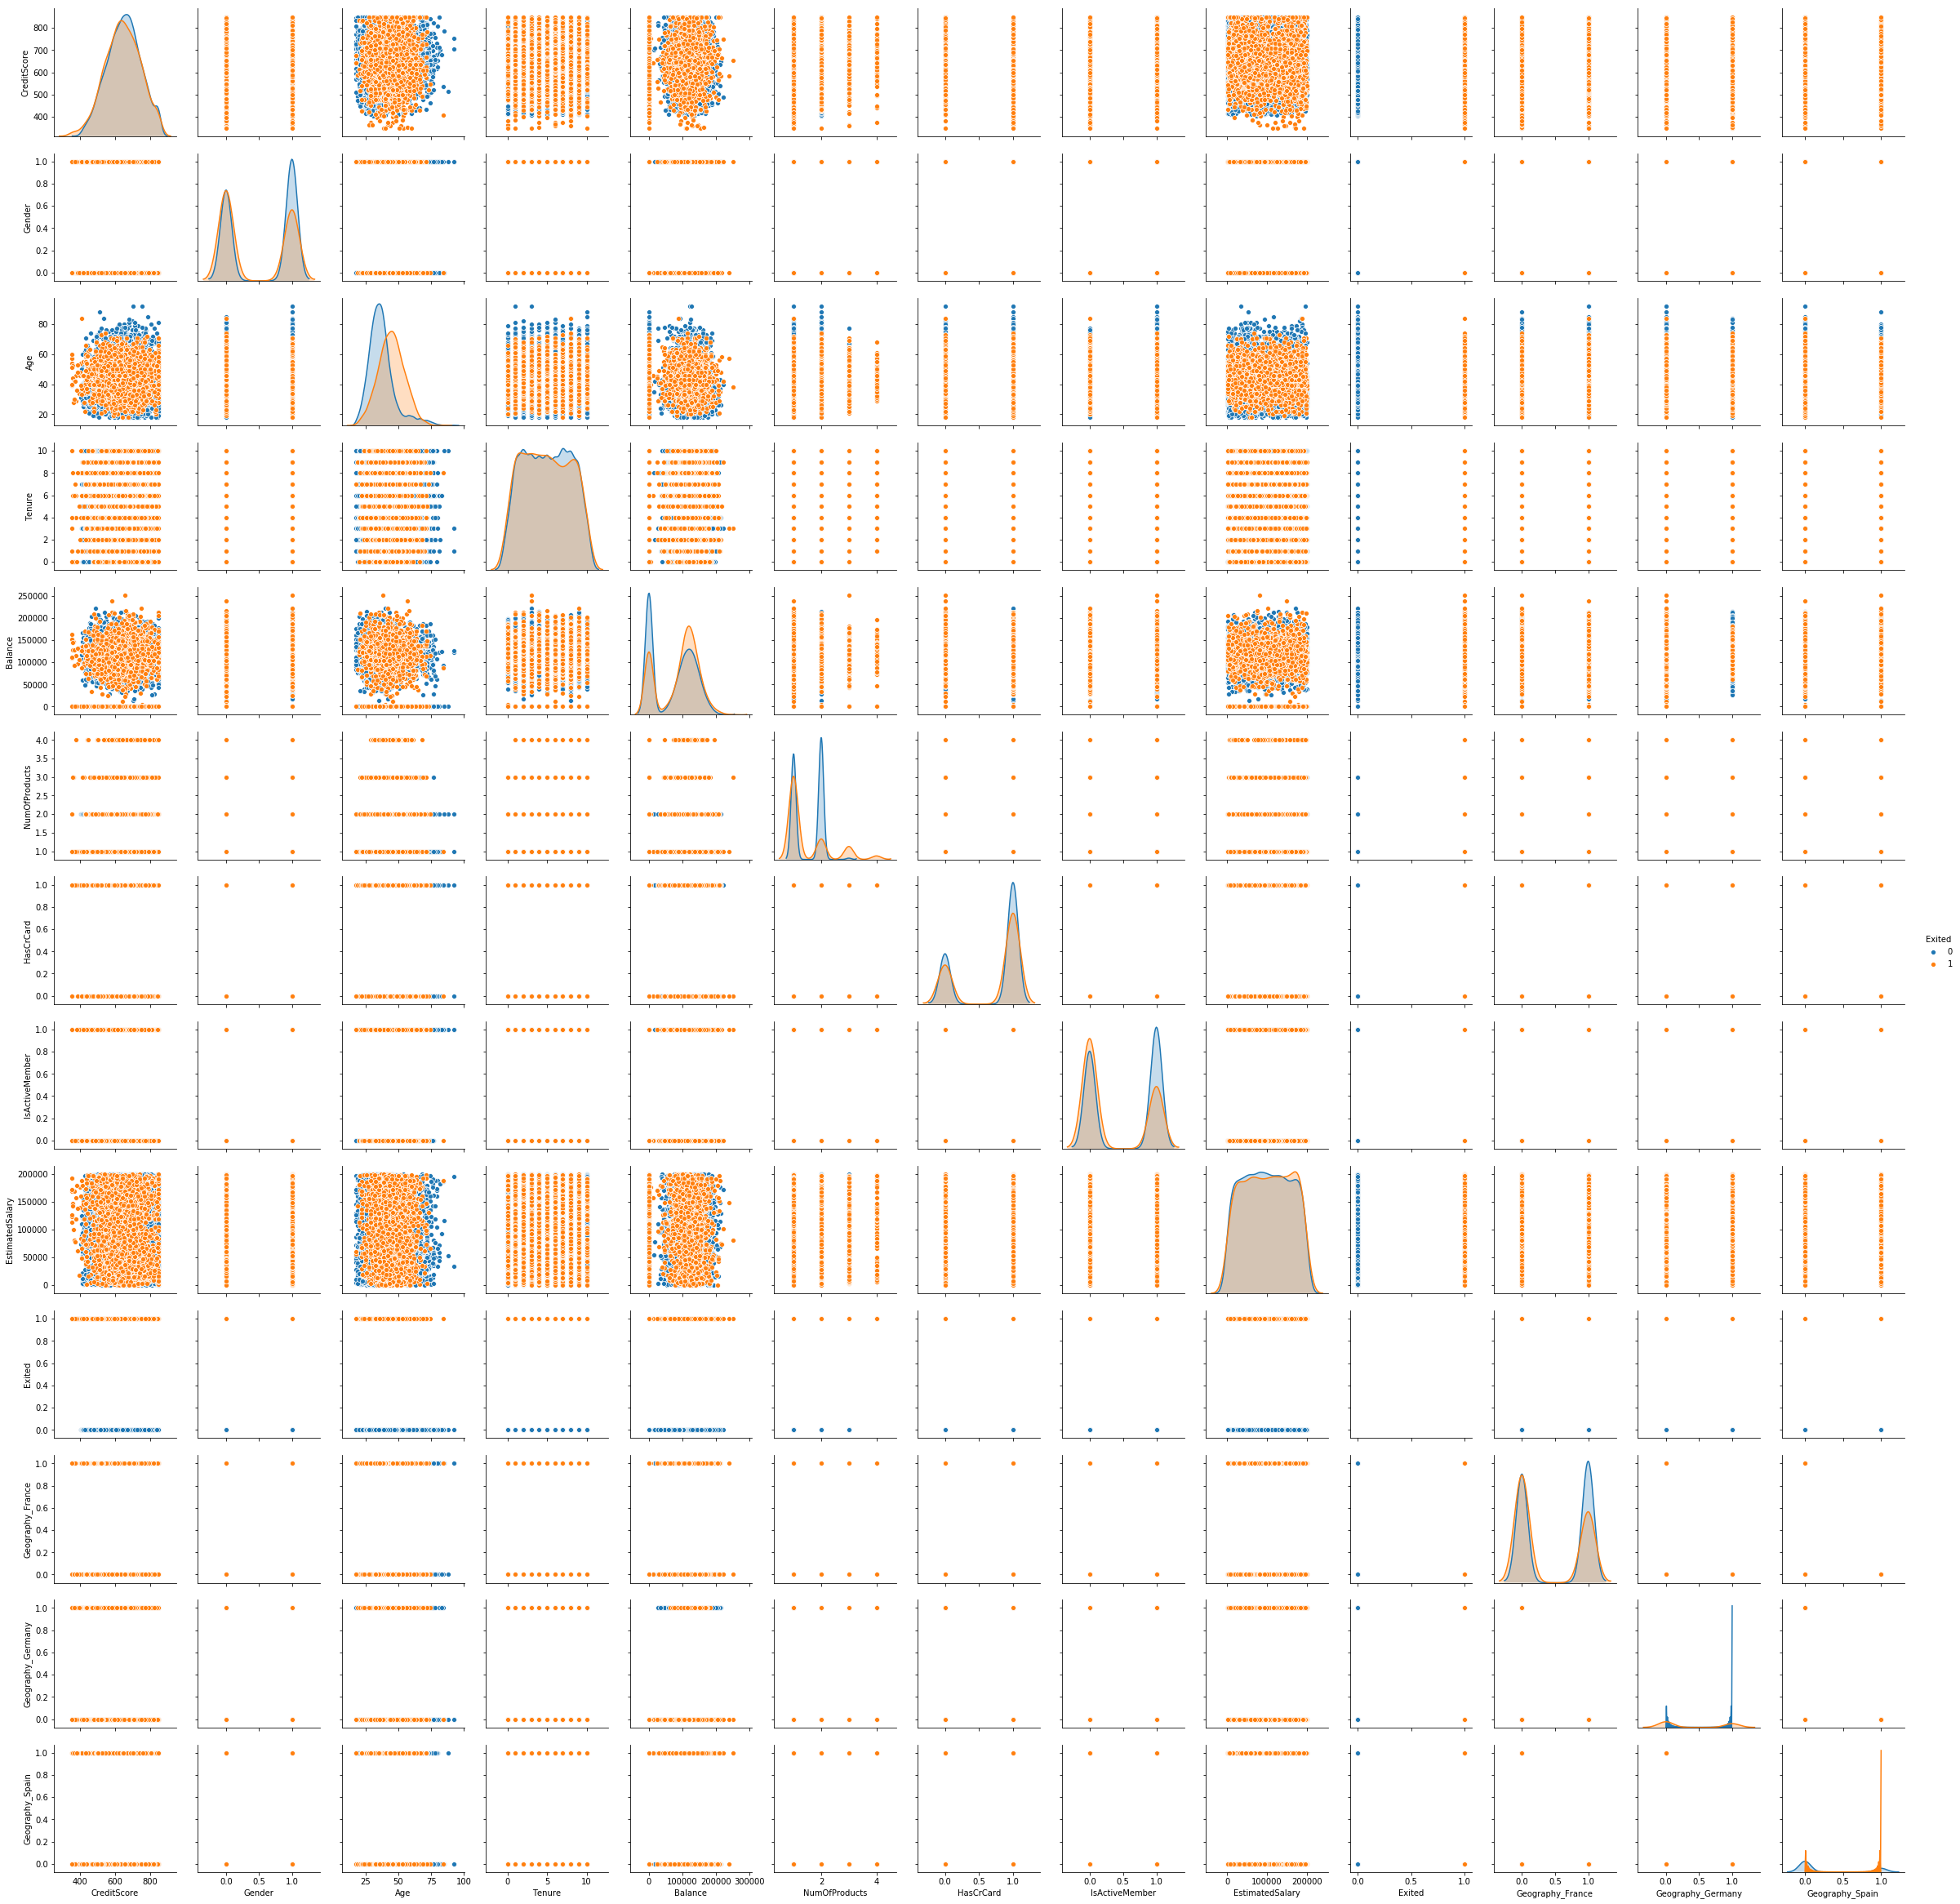

In [12]:
sns.pairplot(bank_data,diag_kind='kde',hue='Exited')

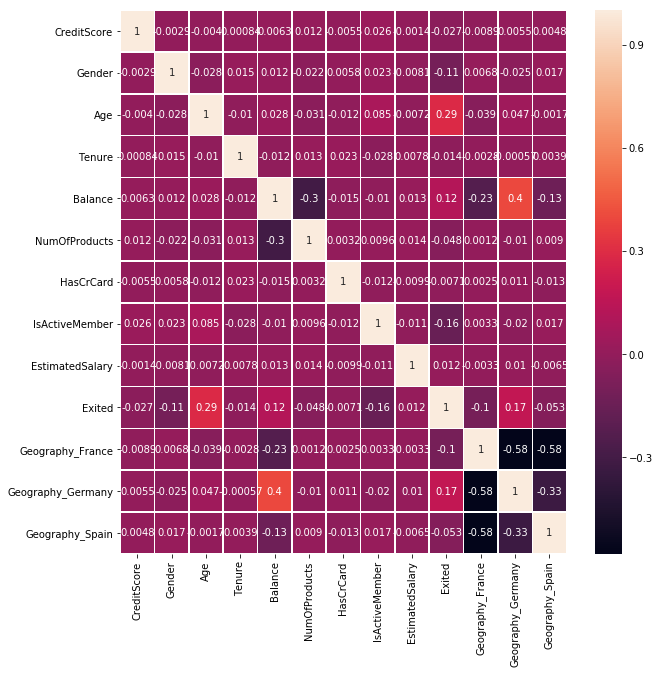

In [13]:
correlation = bank_data.corr()
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(correlation,annot=True,linewidths=0.5,ax=ax)

Features are not correlated.
Data is distrbuted across all the features there is no strong predictor.

**3. Distinguish the feature and target set (5 points)**

In [0]:
X = bank_data.drop('Exited',axis=1)
y = bank_data['Exited']

**4. Divide the data set into Train and test sets**

In [0]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.3,random_state=2)


In [17]:
print('Shape of Xtrain:',X_train.shape)
print('Shape of Xtest:',X_test.shape)
print('Shape of Ytrain:',Y_train.shape)
print('Shape of Ytest:',Y_test.shape)


Shape of Xtrain: (7000, 12)
Shape of Xtest: (3000, 12)
Shape of Ytrain: (7000,)
Shape of Ytest: (3000,)


**5. Normalize the train and test data (5 points)**

In [0]:
sc=StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [19]:
X_train

array([[ 0.40603944, -1.08690612, -1.2255974 , ...,  1.00228833,
        -0.58768841, -0.56877202],
       [-1.05419348, -1.08690612,  0.37842889, ..., -0.99771689,
         1.70158197, -0.56877202],
       [-2.13124471, -1.08690612, -0.84817945, ...,  1.00228833,
        -0.58768841, -0.56877202],
       ...,
       [ 2.06304133,  0.92004266, -0.28205252, ...,  1.00228833,
        -0.58768841, -0.56877202],
       [-1.03348096,  0.92004266,  1.41632826, ..., -0.99771689,
         1.70158197, -0.56877202],
       [ 0.03321401, -1.08690612, -1.03688842, ...,  1.00228833,
        -0.58768841, -0.56877202]])

**6. Initialize & build the model (10 points)**

In [20]:
model = tf.keras.Sequential()

#Add Dense Layer which is basic with 12 input features and one output using sigmoid activation

model.add(tf.keras.layers.Dense(1, input_shape=(12,), activation='sigmoid'))


W0831 09:16:58.734896 140527248107392 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [21]:

model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])


W0831 09:17:03.577646 140527248107392 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/nn_impl.py:180: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


In [22]:
model.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=100)

Train on 7000 samples, validate on 3000 samples
Epoch 1/100
7000/7000 [==============================] - 0s 54us/sample - loss: 0.7181 - acc: 0.5799 - val_loss: 0.6029 - val_acc: 0.6840
Epoch 2/100
7000/7000 [==============================] - 0s 42us/sample - loss: 0.5501 - acc: 0.7464 - val_loss: 0.5035 - val_acc: 0.7883
Epoch 3/100
7000/7000 [==============================] - 0s 44us/sample - loss: 0.4856 - acc: 0.7993 - val_loss: 0.4649 - val_acc: 0.8030
Epoch 4/100
7000/7000 [==============================] - 0s 42us/sample - loss: 0.4586 - acc: 0.8044 - val_loss: 0.4480 - val_acc: 0.8073
Epoch 5/100
7000/7000 [==============================] - 0s 42us/sample - loss: 0.4458 - acc: 0.8064 - val_loss: 0.4397 - val_acc: 0.8070
Epoch 6/100
7000/7000 [==============================] - 0s 44us/sample - loss: 0.4391 - acc: 0.8083 - val_loss: 0.4352 - val_acc: 0.8103
Epoch 7/100
7000/7000 [==============================] - 0s 45us/sample - loss: 0.4353 - acc: 0.8096 - val_loss: 0.4327 - va

In [24]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 1)                 13        
Total params: 13
Trainable params: 13
Non-trainable params: 0
_________________________________________________________________


In [25]:
model.evaluate(X_test, Y_test)

3000/3000 [==============================] - 0s 21us/sample - loss: 0.4287 - acc: 0.8067


[0.42874858713150027, 0.8066667]

**7. Optimize the model (Optional)**

In [0]:
model1 = tf.keras.Sequential()

#Add Dense Layer which provides 100 hidden neurons for 1st layer with relu
model1.add(tf.keras.layers.Dense(100, input_shape=(12,), activation='relu'))

#Add Dense Layer which provides 100 hidden neurons for 1st layer with relu
model1.add(tf.keras.layers.Dense(100,activation='relu'))

#Add Dense Layer which provides 1 outputs after applying sigmoid
model1.add(tf.keras.layers.Dense(1,activation='sigmoid'))

In [0]:
model1.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

In [28]:
model1.fit(X_train, Y_train, validation_data=(X_test, Y_test), epochs=100)

Train on 7000 samples, validate on 3000 samples
Epoch 1/100
7000/7000 [==============================] - 0s 68us/sample - loss: 0.5214 - acc: 0.7914 - val_loss: 0.4755 - val_acc: 0.8050
Epoch 2/100
7000/7000 [==============================] - 0s 53us/sample - loss: 0.4717 - acc: 0.7927 - val_loss: 0.4532 - val_acc: 0.8067
Epoch 3/100
7000/7000 [==============================] - 0s 53us/sample - loss: 0.4494 - acc: 0.7971 - val_loss: 0.4401 - val_acc: 0.8087
Epoch 4/100
7000/7000 [==============================] - 0s 52us/sample - loss: 0.4349 - acc: 0.8046 - val_loss: 0.4324 - val_acc: 0.8127
Epoch 5/100
7000/7000 [==============================] - 0s 57us/sample - loss: 0.4254 - acc: 0.8124 - val_loss: 0.4265 - val_acc: 0.8140
Epoch 6/100
7000/7000 [==============================] - 0s 51us/sample - loss: 0.4186 - acc: 0.8164 - val_loss: 0.4226 - val_acc: 0.8177
Epoch 7/100
7000/7000 [==============================] - 0s 54us/sample - loss: 0.4134 - acc: 0.8186 - val_loss: 0.4195 - va

In [29]:
model1.evaluate(X_test, Y_test)

3000/3000 [==============================] - 0s 23us/sample - loss: 0.3450 - acc: 0.8553


[0.34495027565956116, 0.8553333]

In [30]:
model1.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 100)               1300      
_________________________________________________________________
dense_2 (Dense)              (None, 100)               10100     
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 101       
Total params: 11,501
Trainable params: 11,501
Non-trainable params: 0
_________________________________________________________________


**8. Predict the results using 0.5 as a threshold (Optional)**

In [31]:
y_pred = model1.predict(X_test)
y_pred = (y_pred > 0.5) #to classify each probability into True or False
y_pred[:5]

array([[False],
       [False],
       [False],
       [False],
       [False]])

**9.Print the Accuracy score and confusion matrix (5 points)**

In [32]:
#predicting the results

y_pred = model1.predict(X_test)
y_pred = (y_pred > 0.5) #to classify each probability into True or False

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred)
print (cm, '\n\n', y_pred[:5, :])

[[2288  127]
 [ 307  278]] 

 [[False]
 [False]
 [False]
 [False]
 [False]]


In [33]:
#accuracy
print('Accuracy:',((2330 + 243)/3000))

Accuracy: 0.8576666666666667


In [34]:
model1.evaluate(X_test, Y_test)

3000/3000 [==============================] - 0s 24us/sample - loss: 0.3450 - acc: 0.8553


[0.34495027565956116, 0.8553333]